<a href="https://colab.research.google.com/github/Harshit10880/Chat-logger/blob/main/project2_part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

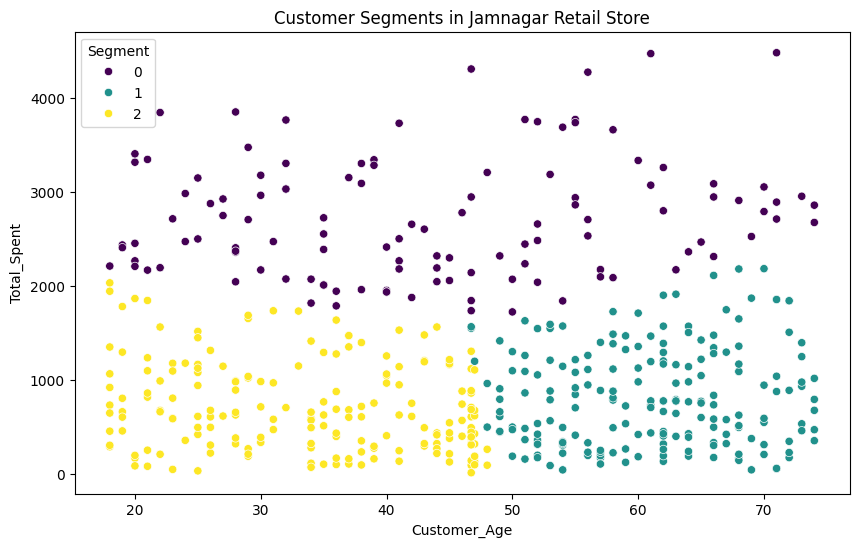

         Customer_Age  Total_Spent
Segment                           
0           43.383522  2707.536723
1           60.992240   818.390905
2           33.949598   703.460052


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

# 1. READ THE CSV
df = pd.read_csv('retail_practice_data_cleaned.csv')

# 2. CLEANING & PRE-PROCESSING
df['Product_Category'] = df['Product_Category'].replace('electrnics', 'Electronics')
df['Customer_Age'] = df['Customer_Age'].fillna(df['Customer_Age'].median())
df_clean = df[df['Total_Spent'] < 50000].copy() # Removing the 99k outlier

# 3. SELECT FEATURES & STANDARDIZE
# We use Age and Money to group people
X = df_clean[['Customer_Age', 'Total_Spent']]

# STANDARDIZATION: Making sure Age and Money are on the same 0-1 scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. IMPLEMENTING THE K-MEANS ALGORITHM (K=3)
kmeans = KMeans(n_clusters=3, random_state=42)
df_clean['Segment'] = kmeans.fit_predict(X_scaled)

# 5. VISUALIZING THE CLUSTERS
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='Customer_Age', y='Total_Spent', hue='Segment', palette='viridis')
plt.title('Customer Segments in Jamnagar Retail Store')
plt.show()

# 6. SEEING THE ACTUAL OUTPUT
print(df_clean.groupby('Segment')[['Customer_Age', 'Total_Spent']].mean())